pip install transformers torch
pip install m3inference
pip install seaborn 

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
import seaborn as sns

In [3]:
with open("anime_comments_all.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
analyzer = SentimentIntensityAnalyzer()

In [4]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    return score["compound"]

display(df.head(5))

,ID,malID,anime_name,user_c,comment,Genres,season
0,1,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Tkit,This is genuinely the most pathetic new mainst...,"Action, Adventure, Fantasy",winter
1,2,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Marinate1016,No amount of memes or social media posts could...,"Action, Adventure, Fantasy",winter
2,3,58567,Ore dake Level Up na Ken Season 2: Arise from ...,keirashii,This review contains spoilers. If we were to f...,"Action, Adventure, Fantasy",winter
3,4,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Bardwyne,"Just as the last season, Solo Leveling s2 has ...","Action, Adventure, Fantasy",winter
4,5,58567,Ore dake Level Up na Ken Season 2: Arise from ...,ShishiKami,It's honestly just as bad as the previous seas...,"Action, Adventure, Fantasy",winter


In [5]:
# วิเคราะห์ sentiment ของ comment
df["sentiment_score"] = df["comment"].apply(get_sentiment)

display(df.head(5))

,ID,malID,anime_name,user_c,comment,Genres,season,sentiment_score
0,1,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Tkit,This is genuinely the most pathetic new mainst...,"Action, Adventure, Fantasy",winter,-0.8229
1,2,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Marinate1016,No amount of memes or social media posts could...,"Action, Adventure, Fantasy",winter,0.9986
2,3,58567,Ore dake Level Up na Ken Season 2: Arise from ...,keirashii,This review contains spoilers. If we were to f...,"Action, Adventure, Fantasy",winter,-0.9999
3,4,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Bardwyne,"Just as the last season, Solo Leveling s2 has ...","Action, Adventure, Fantasy",winter,0.8611
4,5,58567,Ore dake Level Up na Ken Season 2: Arise from ...,ShishiKami,It's honestly just as bad as the previous seas...,"Action, Adventure, Fantasy",winter,-0.8620


In [7]:
# -----------------------------
# 3. แปลงเป็นคะแนน 0-10
# -----------------------------
df["rating"] = (df["sentiment_score"] + 1) * 5
display(df.head(5))

,ID,malID,anime_name,user_c,comment,Genres,season,sentiment_score,rating
0,1,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Tkit,This is genuinely the most pathetic new mainst...,"Action, Adventure, Fantasy",winter,-0.8229,0.8855
1,2,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Marinate1016,No amount of memes or social media posts could...,"Action, Adventure, Fantasy",winter,0.9986,9.9930
2,3,58567,Ore dake Level Up na Ken Season 2: Arise from ...,keirashii,This review contains spoilers. If we were to f...,"Action, Adventure, Fantasy",winter,-0.9999,0.0005
3,4,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Bardwyne,"Just as the last season, Solo Leveling s2 has ...","Action, Adventure, Fantasy",winter,0.8611,9.3055
4,5,58567,Ore dake Level Up na Ken Season 2: Arise from ...,ShishiKami,It's honestly just as bad as the previous seas...,"Action, Adventure, Fantasy",winter,-0.8620,0.6900


In [8]:
# -----------------------------
# 4. แยก genre (กรณีมีหลาย genre)
# -----------------------------
df["Genres"] = df["Genres"].str.split(",")

df = df.explode("Genres")

df["Genres"] = df["Genres"].str.strip()

# -----------------------------
# 5. คำนวณคะแนนเฉลี่ยตาม Genre
# -----------------------------
genre_scores = df.groupby("Genres")["rating"].mean().sort_values(ascending=False)

# print("\nAverage Genre Scores:")
# print(genre_scores)

In [ ]:

# # 1. โหลดโมเดลสำหรับ Gender (ตัวนี้เป็น Public โหลดได้ปกติครับ)
# gender_clf = pipeline("text-classification", model="padmajabfrl/Gender-Classification")

# def analyze_demographics_fast(df):
#     # --- Step 1: Group ข้อมูลเหมือนเดิม ---
#     user_texts_df = df.groupby('user_c')['comment'].apply(lambda x: ' '.join(str(i) for i in x)).reset_index()
    
#     # ดึง list ของคอมเมนต์ออกมา
#     all_texts = user_texts_df['comment'].str.slice(0, 512).tolist()
#     all_users = user_texts_df['user_c'].tolist()

#     print(f"Start Batch Analysis for {len(all_users)} users...")

#     # --- Step 2: ใช้ Batch Processing (ส่งเข้า AI ทีเดียว) ---
#     # ปรับ batch_size ตาม RAM (8, 16, หรือ 32)
#     predictions = gender_clf(all_texts, batch_size=32, truncation=True)

#     # --- Step 3: เก็บผลลัพธ์ ---
#     gender_results = {}
#     age_results = {}

#     for user, pred in zip(all_users, predictions):
#         # เก็บเพศ
#         g_label = pred['label']
#         gender_results[user] = "Male" if "Male" in g_label or "LABEL_1" in g_label else "Female"
        
#         # เก็บอายุ (ใช้ Logic เดิมเพราะเร็วกว่า AI มาก)
#         text_lower = all_texts[all_users.index(user)].lower()
#         if any(w in text_lower for w in ['work', 'job', 'office', 'career', 'wife', 'husband']):
#             age_results[user] = "25-45 (Adult)"
#         elif any(w in text_lower for w in ['school', 'homework', 'study', 'exam', 'mom', 'dad']):
#             age_results[user] = "13-18 (Teen)"
#         else:
#             age_results[user] = "19-24 (Young Adult)"

#     # --- Step 4: Map กลับเข้า df ---
#     df['pred_gender'] = df['user_c'].map(gender_results)
#     df['pred_age_group'] = df['user_c'].map(age_results)
    
#     return df

# # เรียกใช้งาน (เวอร์ชันเร็วกว่าเดิม)
# df = analyze_demographics_fast(df)

# # ตรวจสอบผลลัพธ์ 10 แถวแรก
# print("Analysis Completed!")
# print(df[['user_c', 'comment', 'pred_gender', 'pred_age_group']].head(10))

In [4]:
with open("anime_demographics_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [5]:
display(df.sample(5))

,ID,malID,anime_name,user_c,comment,Genres,season,sentiment_score,rating,pred_gender,pred_age_group
47997,28801,60408,lupin the iiird the movie: fujimi no ketsuzoku,@rensvincentrevamonte2922,hoping for the english dub they should bring b...,Comedy,spring,0.4215,7.1075,Male,19-24 (Young Adult)
72301,42878,61984,bâan: otona no kyoukai,@Danimandius,ive been waiting for so long thank you mr penkin,Fantasy,summer,0.4173,7.0865,Male,19-24 (Young Adult)
126370,77882,60154,Ore wa Seikan Kokka no Akutoku Ryoushu!,tanku,I like fantasy animes but is a crime how few g...,Comedy,spring,0.7419,8.7095,Male,19-24 (Young Adult)
105483,63124,60580,xuan jie zhi men,@JafutoAchumi-s5w9b,donghua name plz,Adventure,fall,0.0772,5.3860,Female,19-24 (Young Adult)
58062,32477,56640,junk world,@Caves69,i trade 2t for a junkbot it is good,Suspense,spring,0.4404,7.2020,Female,19-24 (Young Adult)


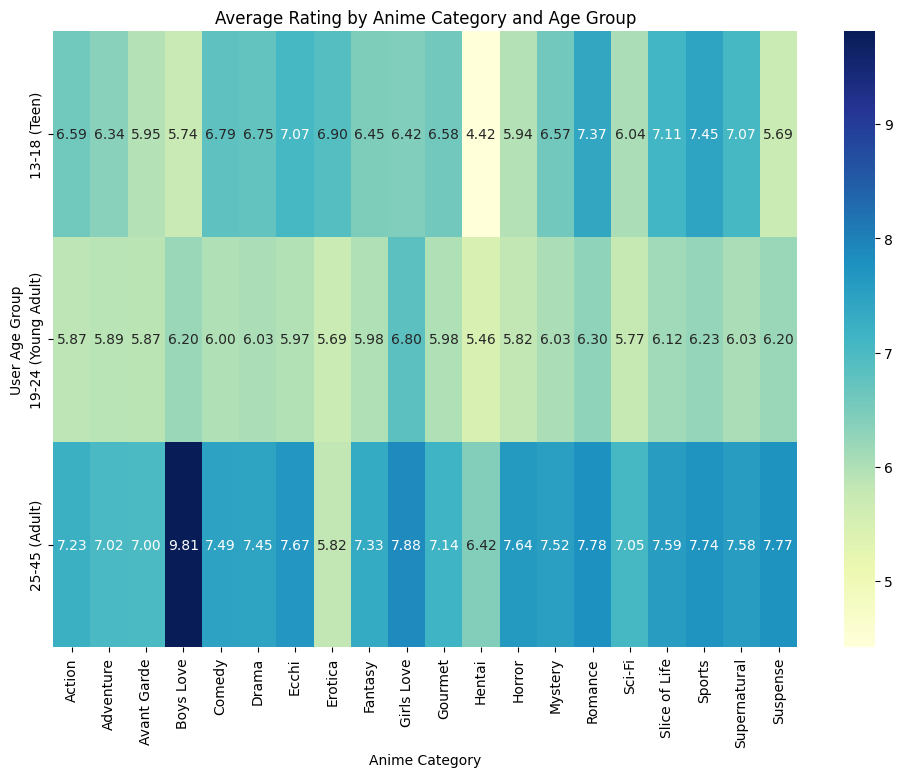

In [ ]:
pivot_table = df.pivot_table(index='pred_age_group', 
                             columns='Genres', 
                             values='rating', 
                             aggfunc='mean')

# 2. วาดกราฟ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.2f')

plt.title('Average Rating by Anime Category and Age Group')
plt.xlabel('Anime Genres')
plt.ylabel('User Age Group')
plt.show()

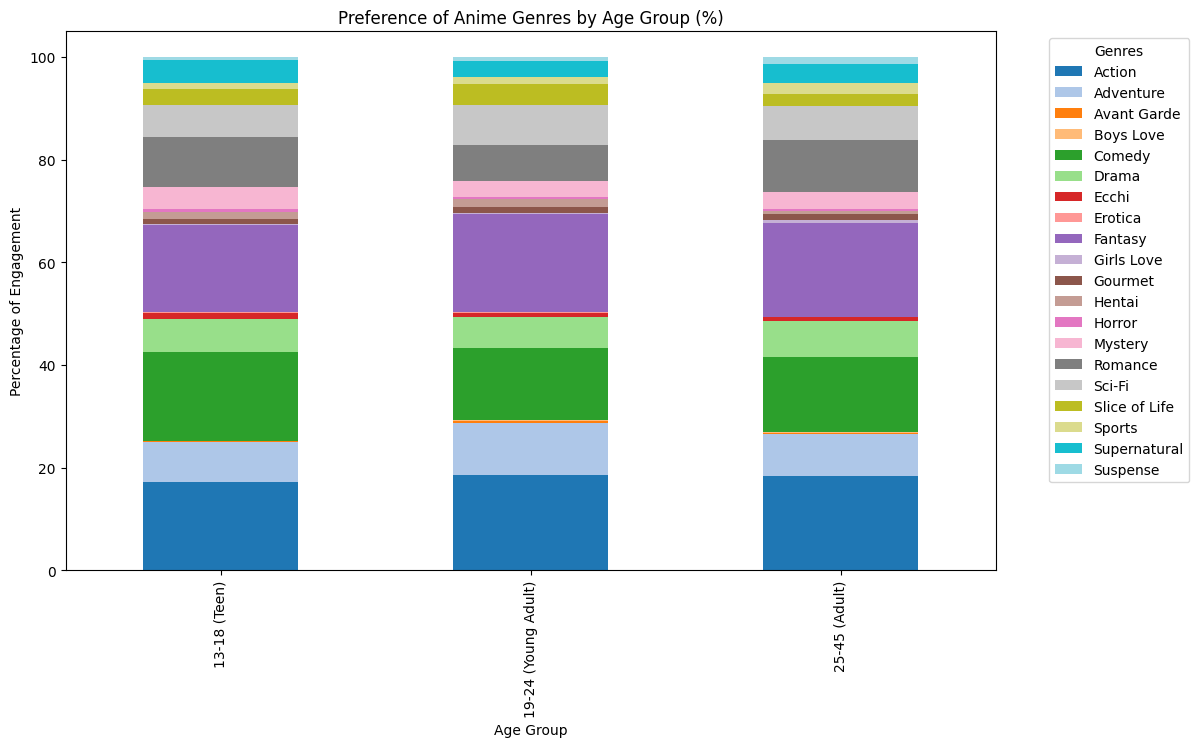

In [10]:

age_cat_counts = pd.crosstab(df['pred_age_group'], df['Genres'], normalize='index') * 100

age_cat_counts.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Preference of Anime Genres by Age Group (%)')
plt.ylabel('Percentage of Engagement')
plt.xlabel('Age Group')
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

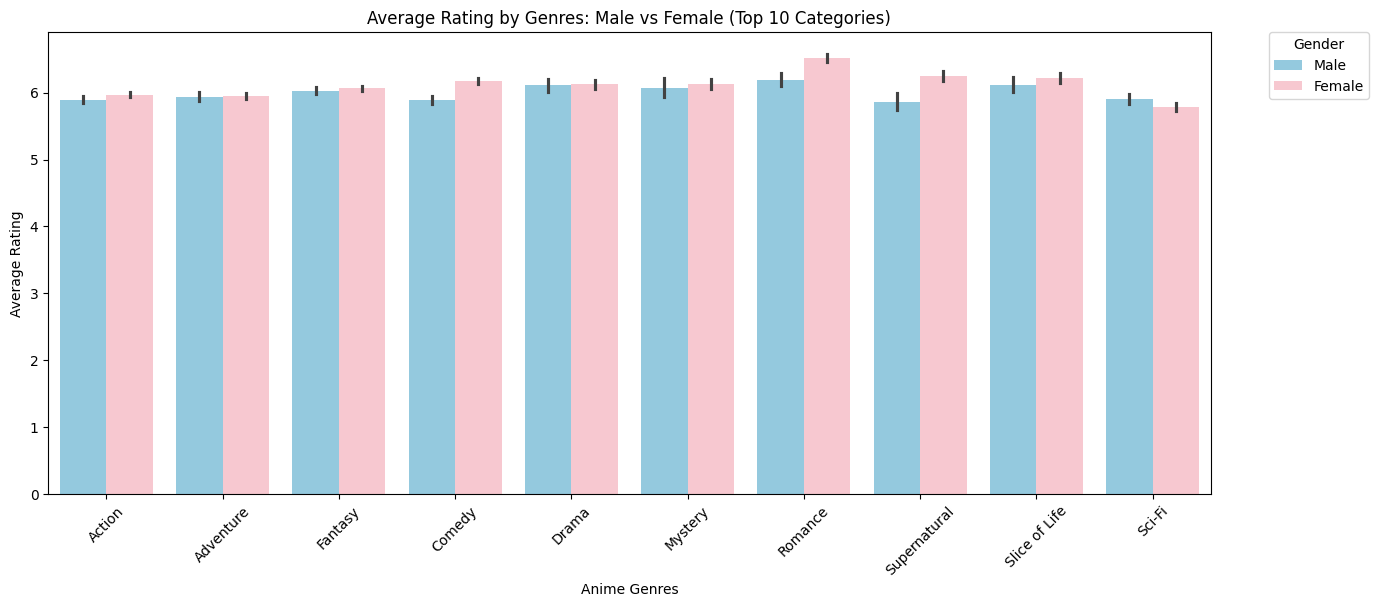

In [19]:
top_categories = df['Genres'].value_counts().nlargest(10).index
df_top = df[df['Genres'].isin(top_categories)]

plt.figure(figsize=(15, 6))
# ใช้ hue='pred_gender' เพื่อแยกสีตามเพศ
sns.barplot(data=df_top, x='Genres', y='rating', hue='pred_gender', palette=['skyblue', 'pink'])

plt.title('Average Rating by Genres: Male vs Female (Top 10 Categories)')
plt.ylabel('Average Rating')
plt.xlabel('Anime Genres')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xticks(rotation=45)
plt.show()

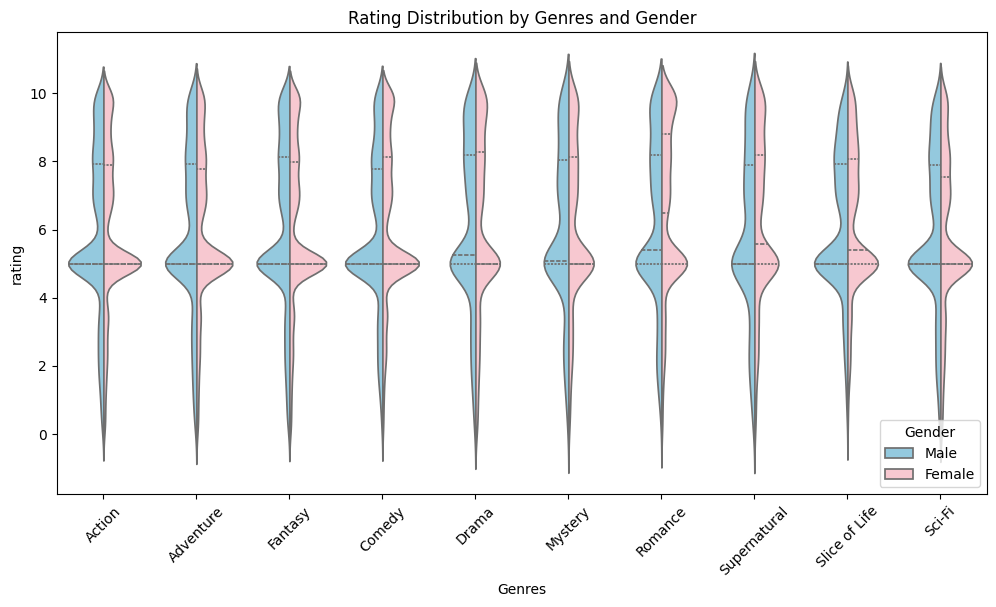

In [18]:
plt.figure(figsize=(12, 6))
# split=True จะทำให้เราเห็นการเปรียบเทียบซ้าย-ขวาในอันเดียวกัน
sns.violinplot(data=df_top, x='Genres', y='rating', hue='pred_gender', 
               split=True, inner="quart", palette=['skyblue', 'pink'])
plt.legend(title='Gender',loc='lower right')
plt.title('Rating Distribution by Genres and Gender')
plt.xticks(rotation=45)
plt.show()

In [ ]:
anime_scores = df.groupby("anime_name")["rating"].mean().sort_values(ascending=False)

print("\nAverage Anime Scores:")
# print(anime_scores)



Average Anime Scores:


กราฟสำหรับ ภาพรวม

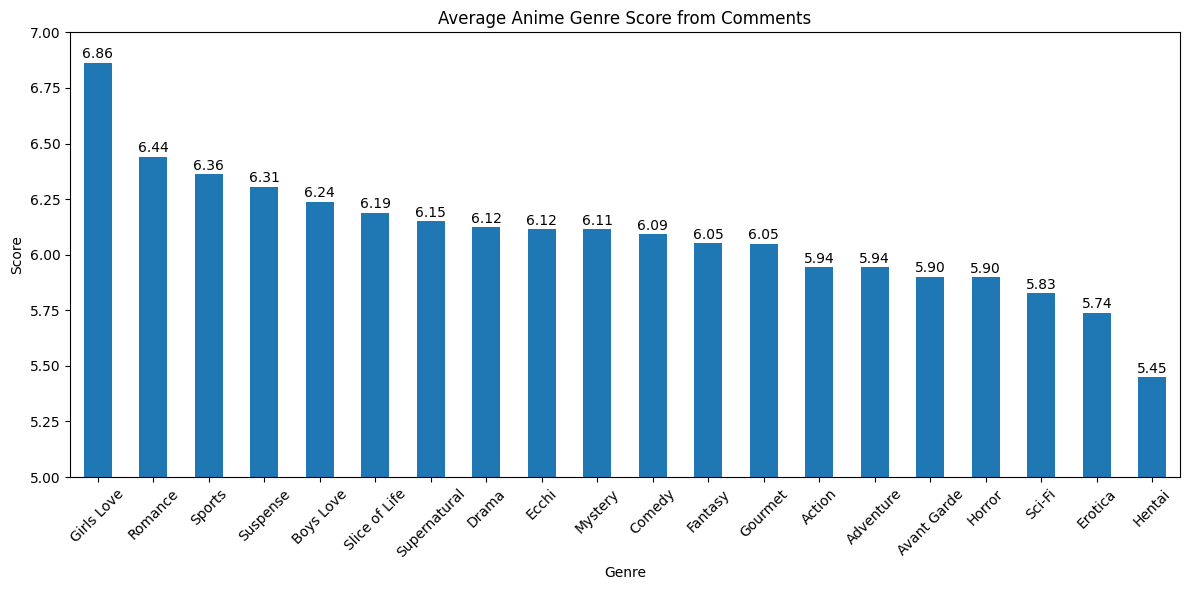

In [12]:
plt.figure(figsize=(12,6))

genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments")
plt.xlabel("Genre")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.ylim(5,7)

for i, v in enumerate(genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()

plt.show()

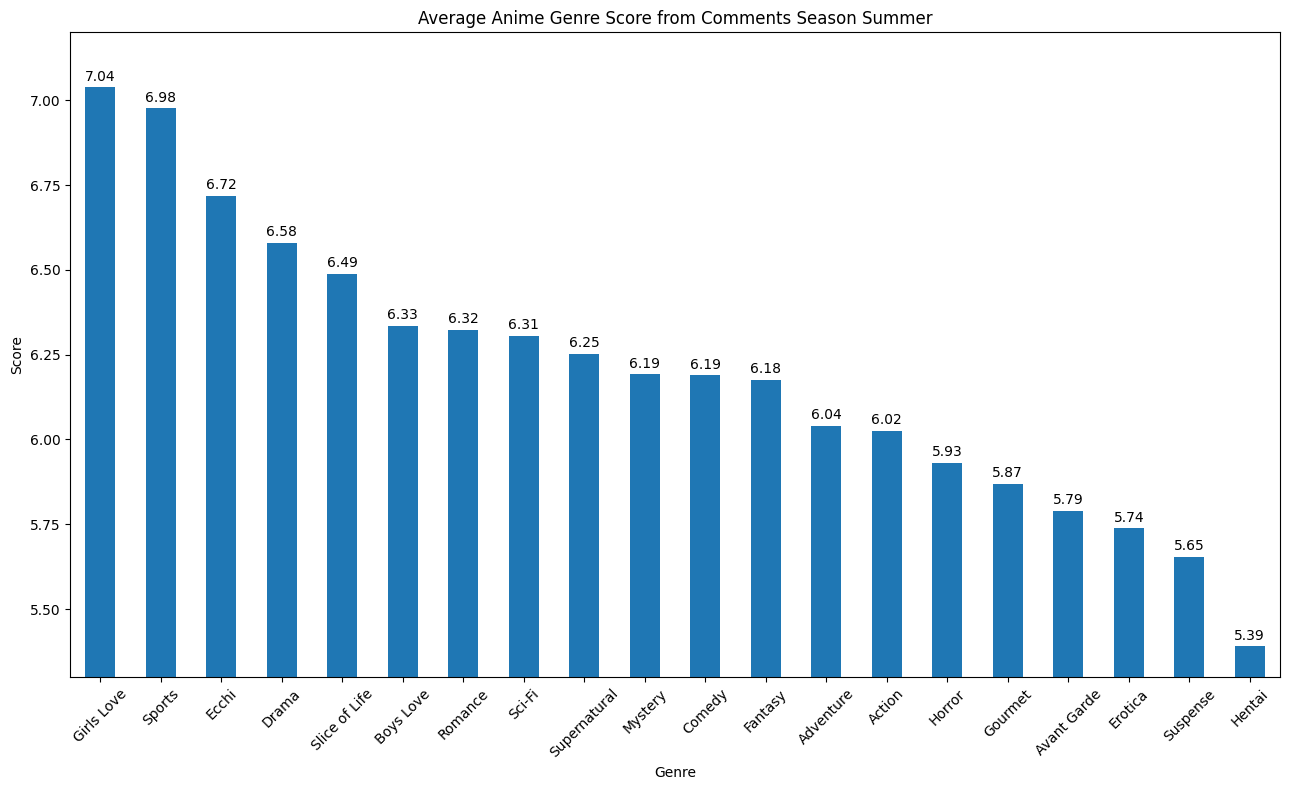

In [19]:

summer_genre_scores = df.loc[df['season']=="summer"].groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(13,8))

# ใช้ตัวแปรที่กลุ่มข้อมูลมาแล้ว
summer_genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments Season Summer")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45)

# ปรับจุดต่ำสุดให้ใกล้เคียงกับข้อมูล (จากรูป ค่าต่ำสุดคือ 5.39)
plt.ylim(5.3, 7.2) 

for i, v in enumerate(summer_genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

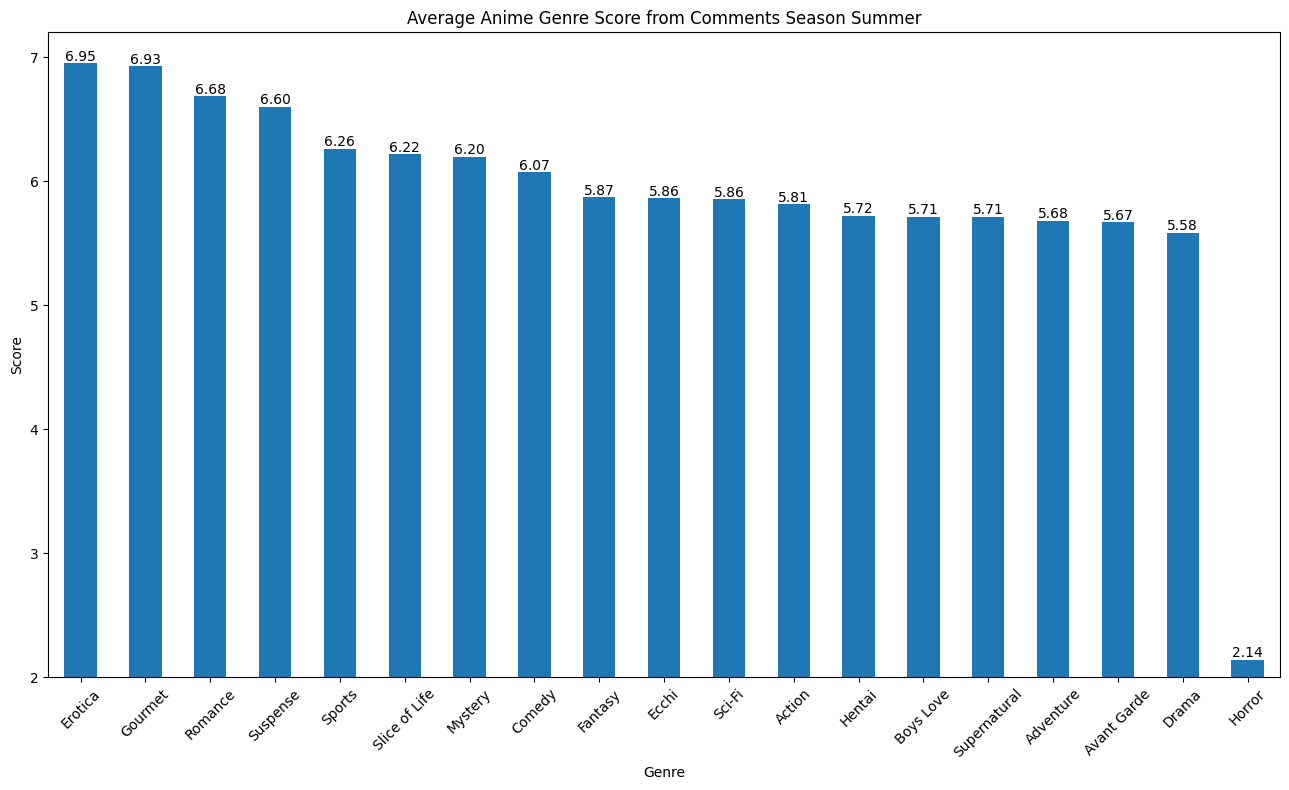

In [ ]:
spring_genre_scores = df.loc[df['season']=="spring"].groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(13,8))

# ใช้ตัวแปรที่กลุ่มข้อมูลมาแล้ว
spring_genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments Season Spring")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45)


plt.ylim(2, 7.2) 

for i, v in enumerate(spring_genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

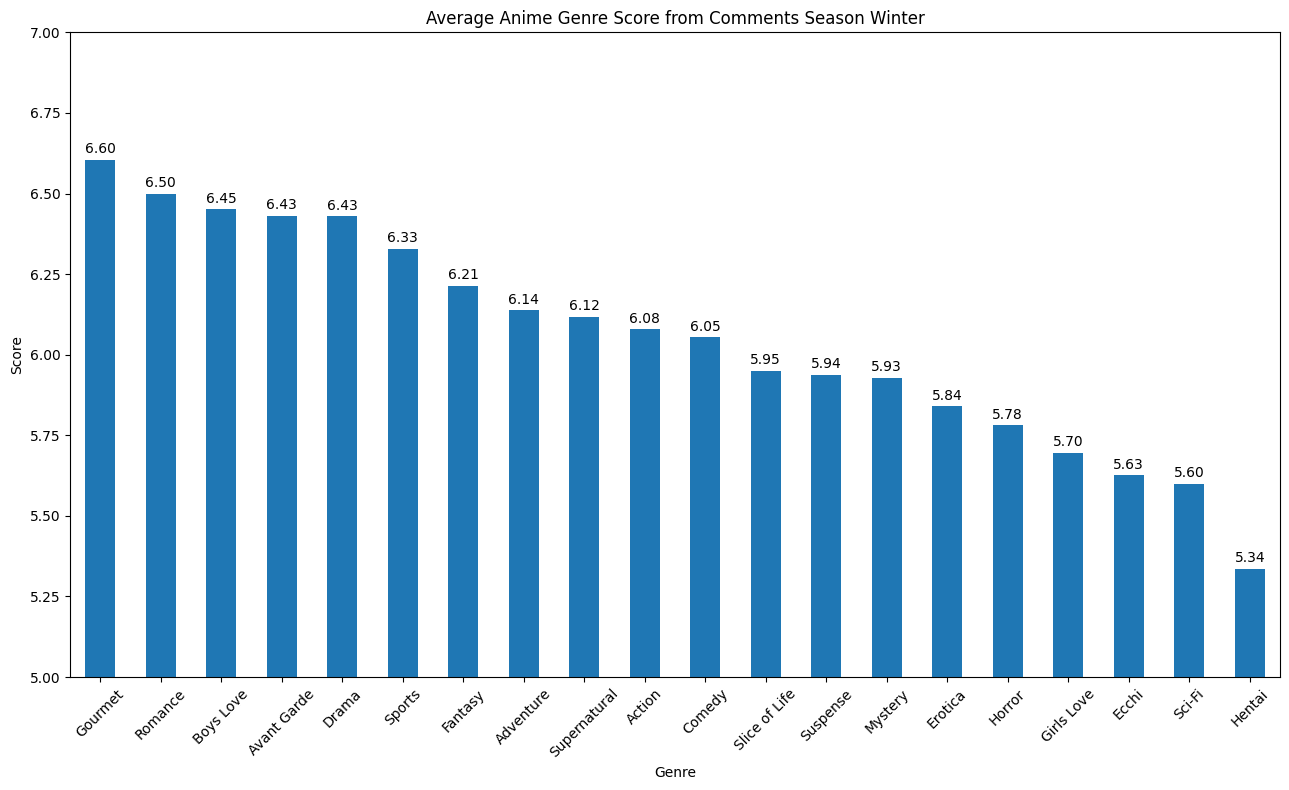

In [ ]:
winter_genre_scores = df.loc[df['season']=="winter"].groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(13,8))


winter_genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments Season Winter")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45)


plt.ylim(5,7)

for i, v in enumerate(winter_genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

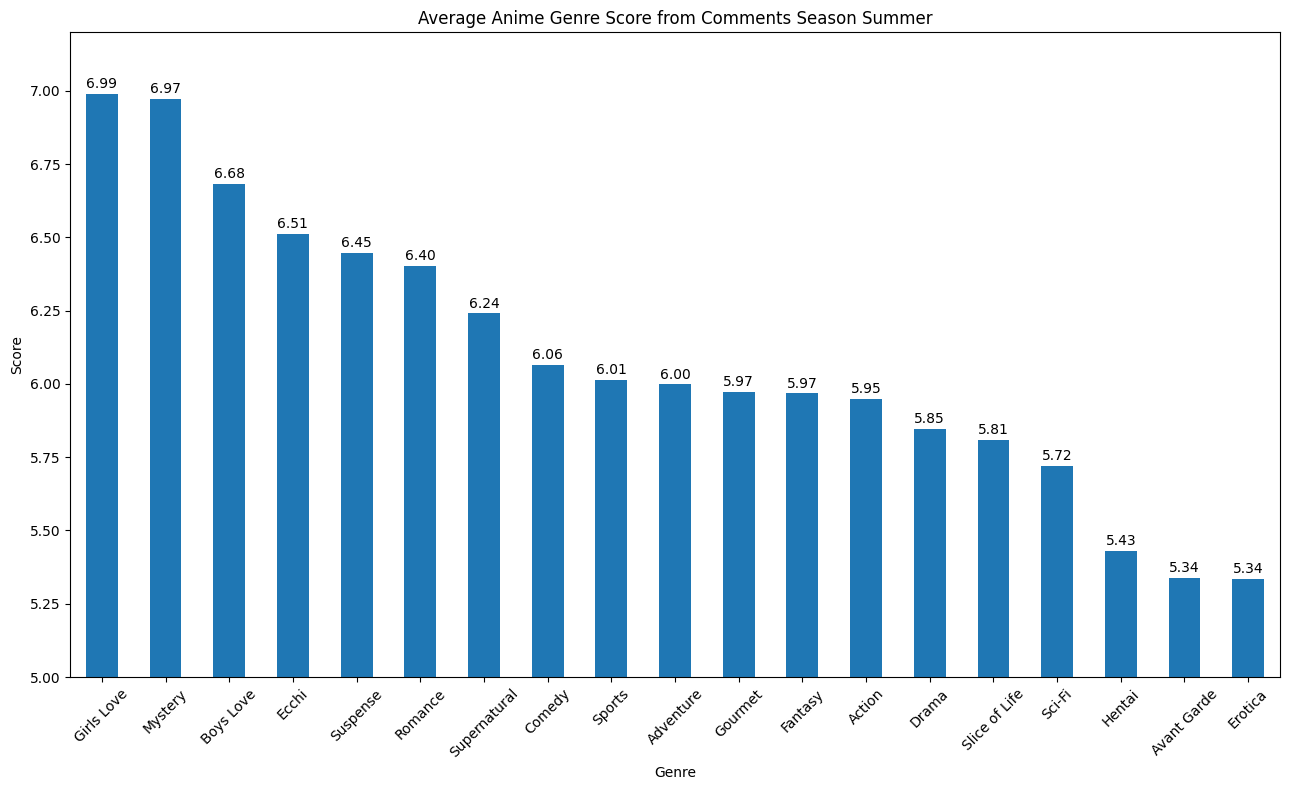

In [ ]:
fall_genre_scores = df.loc[df['season']=="fall"].groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(13,8))

fall_genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments Season Summer")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45)


plt.ylim(5, 7.2) 

for i, v in enumerate(fall_genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()